In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import norm,binom,poisson,geom, expon

In [17]:
data = pd.read_csv('walmart_data.csv')

In [18]:
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


Q1 Import the dataset and do usual data analysis steps like checking the structure &
characteristics of the dataset  

a) The data type of all columns in the “customers” table.

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


Observation:
1. User_id, occuoation, marital_status, product_category and purchase have integer data type.
2. Product_id, age, gender, city category & stay in current city years have object datatype.

b) You can ﬁnd the number of rows and columns given in the dataset.

In [20]:
data.shape

(550068, 10)

observation: There are 10 columns and 550068 rows.

c) Check for the missing values and ﬁnd the number of missing values in each
column.

In [21]:
data.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


Insights:
There are no null enties in entire dataset.

Q2 Detect Null values and outliers.

a) Find the outliers for every continuous variable in the dataset.

<Axes: ylabel='Occupation'>

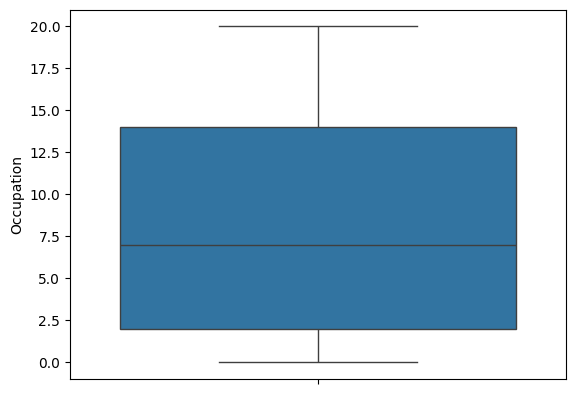

In [22]:
sns.boxplot(data['Occupation'])

Insights: There are no outliers in occupation coloumn.

<Axes: ylabel='Product_Category'>

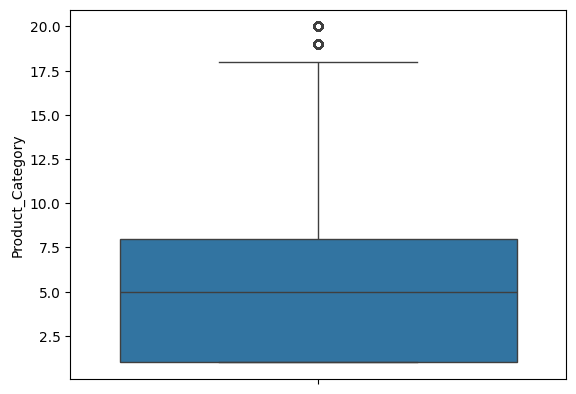

In [23]:
sns.boxplot(data['Product_Category'])

Insights:
There are two outliers in product category column.

<Axes: ylabel='Purchase'>

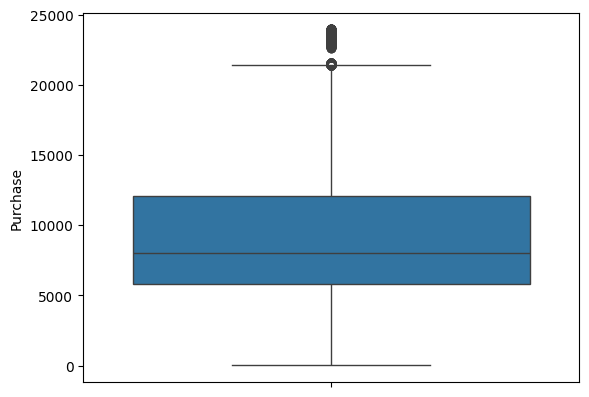

In [24]:
sns.boxplot(data['Purchase'])

Insight:
Purchase column has multiple outliers.

b)  Remove/clip the data between the 5 percentile and 95 percentile.

Clipping of product category column.

In [27]:
clipped_product_category = np.clip(data['Product_Category'], a_min= data['Product_Category'].quantile(0.05), a_max= data['Product_Category'].quantile(0.95))
clipped_product_category

,Product_Category
0,3
1,1
2,12
3,12
4,8
...,...
550063,13
550064,13
550065,13
550066,13


In [28]:
clipped_purchase = np.clip(data['Purchase'], a_min= data['Purchase'].quantile(0.05), a_max= data['Purchase'].quantile(0.95))
clipped_purchase

,Purchase
0,8370
1,15200
2,1984
3,1984
4,7969
...,...
550063,1984
550064,1984
550065,1984
550066,1984


Q3 Data Exploration.

a)  What products are different age groups buying?

In [42]:
values = [1,5,10,15,20]
names = ['pro_cat_1 to 5','pro_cat_5 to 10','pro_cat_10 to 15','pro_cat_15 to 20']
data['product_category_range'] = pd.cut(data['Product_Category'],values,labels =names)
data['product_category_range'].value_counts()

,count
product_category_range,
pro_cat_1 to 5,206763
pro_cat_5 to 10,143647
pro_cat_10 to 15,41596
pro_cat_15 to 20,17684


<Axes: xlabel='Age', ylabel='Count'>

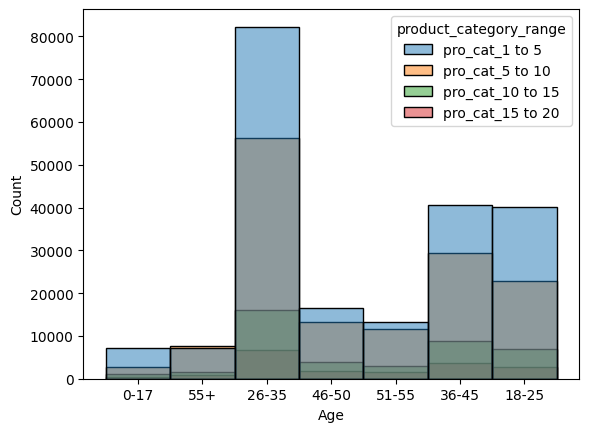

In [43]:
sns.histplot(data=data, x='Age', hue='product_category_range')

<Axes: xlabel='Age', ylabel='count'>

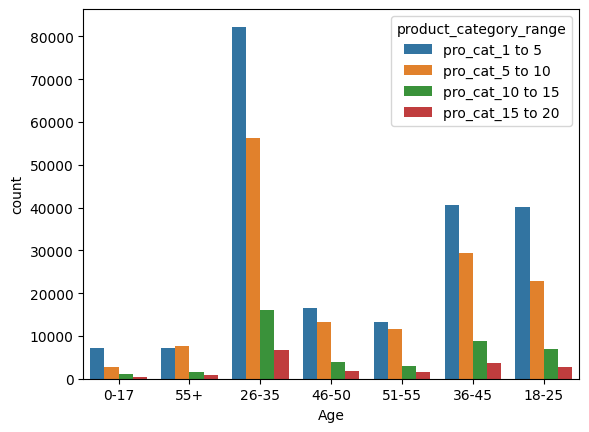

In [46]:
sns.countplot(data=data, x='Age', hue='product_category_range')

b) Is there a relationship between age, marital status, and the amount spent?

In [55]:
data['Purchase'].aggregate([min,max])

<ipython-input-55-a707e115b33c>:1: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  data['Purchase'].aggregate([min,max])
<ipython-input-55-a707e115b33c>:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  data['Purchase'].aggregate([min,max])


,Purchase
min,12
max,23961


<Axes: xlabel='Purchase_range', ylabel='count'>

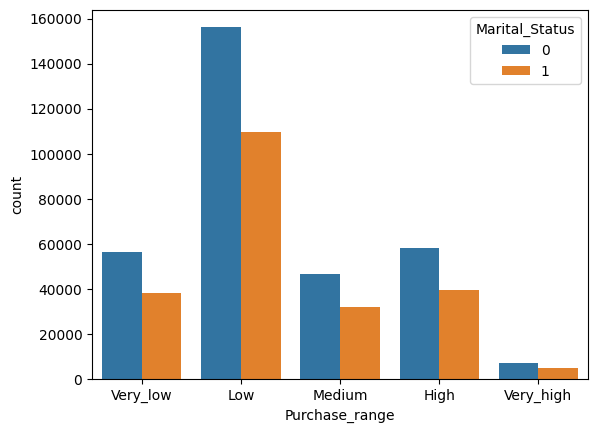

In [56]:
values1 = [0,5000,10000,15000,20000,25000]
names1 = ['Very_low','Low','Medium','High','Very_high']
data['Purchase_range'] = pd.cut(data['Purchase'],values1,labels =names1)
data['Purchase_range'].value_counts()
sns.countplot(data=data,x= 'Purchase_range',  hue= 'Marital_Status')

<Axes: xlabel='Age', ylabel='count'>

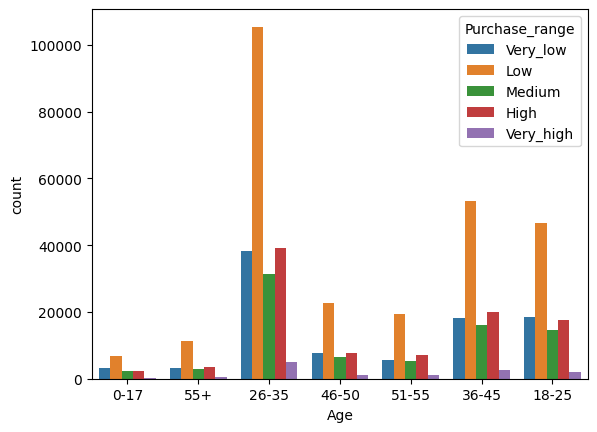

In [57]:
sns.countplot(data=data,x= 'Age',  hue= 'Purchase_range')

<Axes: xlabel='Product_Category', ylabel='count'>

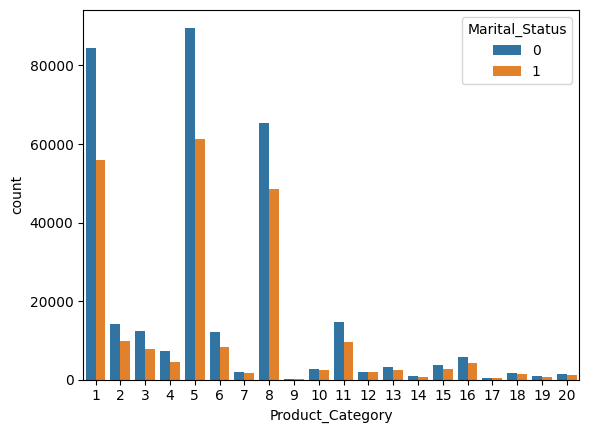

In [50]:
sns.countplot(data=data, x='Product_Category', hue='Marital_Status')

<Axes: xlabel='Purchase', ylabel='Product_Category'>

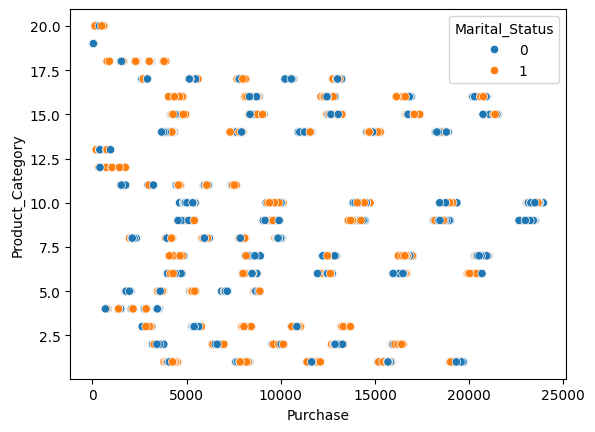

In [54]:
sns.scatterplot(data=data, x='Purchase', y='Product_Category', hue='Marital_Status')

# **Q4 How does gender affect the amount spent?**

In [66]:
data.groupby(data['Gender'])['Purchase'].aggregate([np.mean,np.std])

<ipython-input-66-e45cca737d3d>:1: FutureWarning: The provided callable <function mean at 0x79ee49101000> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby(data['Gender'])['Purchase'].aggregate([np.mean,np.std])
<ipython-input-66-e45cca737d3d>:1: FutureWarning: The provided callable <function std at 0x79ee49101120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data.groupby(data['Gender'])['Purchase'].aggregate([np.mean,np.std])


,mean,std
Gender,,
F,8734.565765,4767.233289
M,9437.526040,5092.186210


In [83]:
male_mean = data[data['Gender']=='M']['Purchase'].mean()
male_std = data[data['Gender']=='M']['Purchase'].std()
female_mean = data[data['Gender']=='F']['Purchase'].mean()
female_std = data[data['Gender']=='F']['Purchase'].std()


95 % confidence interval for whole data of male gender.

In [100]:
m1 =np.percentile(data[data['Gender']=='M']['Purchase'],2.5)
m2=np.percentile(data[data['Gender']=='M']['Purchase'],95)
m1,m2

(1436.0, 19378.0)

In [101]:
f1 =np.percentile(data[data['Gender']=='F']['Purchase'],2.5)
f2=np.percentile(data[data['Gender']=='F']['Purchase'],95)
f1,f2

(1376.0, 19148.0)

Insight:

With 95 % confidence we can say that purchase amount will be in between 1436 and 19378.

# **A) CLT method**

a) 95 % confidence interval for sample size of 300 by CLT method for male gender.

In [86]:
norm.interval(0.95, loc = male_mean, scale = male_std/(300**0.5))

(8861.301513447852, 10013.750567496678)

b) 95 % confidence interval for sample size of 3000 by CLT method for male gender.

In [87]:
norm.interval(0.95, loc = male_mean, scale = male_std/(3000**0.5))

(9255.307845567226, 9619.744235377304)

c) 95 % confidence interval for sample size of 30000 by CLT method for male gender.

In [88]:
norm.interval(0.95, loc = male_mean, scale = male_std/(30000**0.5))

(9379.903587769824, 9495.148493174705)

d) 95 % confidence interval for sample size of 300 by CLT method for female gender.

In [89]:
norm.interval(0.95, loc = female_mean, scale = female_std/(300**0.5))

(8195.112447037955, 9274.019083272997)

e) 95 % confidence interval for sample size of 3000 by CLT method for female gender.

In [99]:
norm.interval(0.95, loc = female_mean, scale = female_std/(3000**0.5))

(8563.975647496802, 8905.15588281415)

f) 95 % confidence interval for sample size of 30000 by CLT method for female gender.

In [91]:
norm.interval(0.95, loc = female_mean, scale = female_std/(30000**0.5))

(8680.620433343724, 8788.511096967228)

# B) **Bootstrapping Method**

a) 95 % confidence interval for sample size of 300 by bootstrapping method for male gender.

In [93]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='M']['Purchase'], size=300)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
x1 = np.percentile(bootstrapped_means, 2.5)
x2 = np.percentile(bootstrapped_means, 97.5)
x1,x2

(8912.663833333332, 10006.342916666666)

b) 95 % confidence interval for sample size of 3000 by bootstrapping method for male gender.

In [94]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='M']['Purchase'], size=3000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
y1 = np.percentile(bootstrapped_means, 2.5)
y2 = np.percentile(bootstrapped_means, 97.5)
y1,y2

(9267.856641666667, 9622.149308333333)

c) 95 % confidence interval for sample size of 30000 by bootstrapping method for male gender.

In [95]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='M']['Purchase'], size=30000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
z1 = np.percentile(bootstrapped_means, 2.5)
z2 = np.percentile(bootstrapped_means, 97.5)
z1,z2

(9379.1443475, 9492.438526666667)

e) 95 % confidence interval for sample size of 300 by bootstrapping method for female gender.

In [96]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='F']['Purchase'], size=300)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
a1 = np.percentile(bootstrapped_means, 2.5)
a2 = np.percentile(bootstrapped_means, 97.5)
a1,a2

(8180.350083333333, 9295.279499999999)

f) 95 % confidence interval for sample size of 3000 by bootstrapping method for female gender.

In [97]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='F']['Purchase'], size=3000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
b1 = np.percentile(bootstrapped_means, 2.5)
b2 = np.percentile(bootstrapped_means, 97.5)
b1,b2

(8564.751641666668, 8904.112275000001)

g) 95 % confidence interval for sample size of 30000 by bootstrapping method for female gender.

In [98]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Gender']=='F']['Purchase'], size=30000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
c1 = np.percentile(bootstrapped_means, 2.5)
c2 = np.percentile(bootstrapped_means, 97.5)
c1,c2

(8677.270148333333, 8783.6265325)

# **Q 5. How does Marital_Status affect the amount spent?**

In [103]:
data.groupby(data['Marital_Status'])['Purchase'].aggregate([np.mean,np.std])

<ipython-input-103-0554c54fee9b>:1: FutureWarning: The provided callable <function mean at 0x79ee49101000> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby(data['Marital_Status'])['Purchase'].aggregate([np.mean,np.std])
<ipython-input-103-0554c54fee9b>:1: FutureWarning: The provided callable <function std at 0x79ee49101120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data.groupby(data['Marital_Status'])['Purchase'].aggregate([np.mean,np.std])


,mean,std
Marital_Status,,
0,9265.907619,5027.347859
1,9261.174574,5016.897378


In [110]:
unmarried_mean = data[data['Marital_Status']== 0]['Purchase'].mean()
unmarried_std = data[data['Marital_Status']== 0]['Purchase'].std()
married_mean = data[data['Marital_Status']== 1]['Purchase'].mean()
married_std = data[data['Marital_Status']== 1]['Purchase'].std()

# **A) CLT method**
a) 95 % confidence interval for sample size of 300 by CLT method for unmarried marital status.

In [111]:
norm.interval(0.95, loc = unmarried_mean, scale = unmarried_std/(300**0.5))

(8697.020107210066, 9834.795130632947)

b) 95 % confidence interval for sample size of 3000 by CLT method for unmarried marital status.

In [112]:
norm.interval(0.95, loc = unmarried_mean, scale = unmarried_std/(3000**0.5))

(9086.00959197812, 9445.805645864893)

c) 95 % confidence interval for sample size of 30000 by CLT method for unmarried marital status.

In [113]:
norm.interval(0.95, loc = unmarried_mean, scale = unmarried_std/(30000**0.5))

(9209.018867750363, 9322.79637009265)

d) 95 % confidence interval for sample size of 300 by CLT method for married marital status.

In [114]:
norm.interval(0.95, loc = married_mean, scale = married_std/(300**0.5))

(8693.469623878887, 9828.87952428586)

e) 95 % confidence interval for sample size of 3000 by CLT method for married marital status.

In [115]:
norm.interval(0.95, loc = married_mean, scale = married_std/(3000**0.5))

(9081.650505922826, 9440.698642241921)

f) 95 % confidence interval for sample size of 3000 by CLT method for married marital status.

In [116]:
norm.interval(0.95, loc = married_mean, scale = married_std/(30000**0.5))

(9204.404079062026, 9317.945069102721)

# **B) Bootstrapping Method**
a) 95 % confidence interval for sample size of 300 by bootstrapping method for unmarried marital status.

In [117]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==0]['Purchase'], size=300)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
u1 = np.percentile(bootstrapped_means, 2.5)
u2 = np.percentile(bootstrapped_means, 97.5)
u1,u2

(8702.753416666666, 9833.958499999999)

b) 95 % confidence interval for sample size of 3000 by bootstrapping method for unmarried marital status.

In [118]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==0]['Purchase'], size=3000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
u1 = np.percentile(bootstrapped_means, 2.5)
u2 = np.percentile(bootstrapped_means, 97.5)
u1,u2

(9086.860641666666, 9457.096633333333)

c) 95 % confidence interval for sample size of 30000 by bootstrapping method for unmarried marital status.

In [119]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==0]['Purchase'], size=30000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
u1 = np.percentile(bootstrapped_means, 2.5)
u2 = np.percentile(bootstrapped_means, 97.5)
u1,u2

(9208.975279166665, 9322.807875833334)

d) 95 % confidence interval for sample size of 300 by bootstrapping method for married marital status.

In [120]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==1]['Purchase'], size=300)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
m1 = np.percentile(bootstrapped_means, 2.5)
m2 = np.percentile(bootstrapped_means, 97.5)
m1,m2

(8655.613416666667, 9827.169166666667)

e) 95 % confidence interval for sample size of 3000 by bootstrapping method for married marital status.

In [121]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==1]['Purchase'], size=3000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
m1 = np.percentile(bootstrapped_means, 2.5)
m2 = np.percentile(bootstrapped_means, 97.5)
m1,m2

(9074.480458333333, 9454.9246)

f) 95 % confidence interval for sample size of 30000 by bootstrapping method for married marital status.

In [122]:
bootstrapped_means = []
for reps in range(1000):
    bootstrapped_sample = np.random.choice(data[data['Marital_Status']==1]['Purchase'], size=30000)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrapped_means.append(bootstrapped_mean)
m1 = np.percentile(bootstrapped_means, 2.5)
m2 = np.percentile(bootstrapped_means, 97.5)
m1,m2

(9206.1776425, 9317.015193333335)

# **Q 6. How does Age affect the amount spent?**

In [124]:
data['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [129]:
data.groupby(data['Age'])['Purchase'].aggregate([np.mean,np.std])

<ipython-input-129-05fe6d50e163>:1: FutureWarning: The provided callable <function mean at 0x79ee49101000> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data.groupby(data['Age'])['Purchase'].aggregate([np.mean,np.std])
<ipython-input-129-05fe6d50e163>:1: FutureWarning: The provided callable <function std at 0x79ee49101120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data.groupby(data['Age'])['Purchase'].aggregate([np.mean,np.std])


,mean,std
Age,,
0-17,8933.464640,5111.114046
18-25,9169.663606,5034.321997
26-35,9252.690633,5010.527303
36-45,9331.350695,5022.923879
46-50,9208.625697,4967.216367
51-55,9534.808031,5087.368080
55+,9336.280459,5011.493996


**Age : 0-17**

In [125]:
mean1 = data[data['Age']=='0-17']['Purchase'].mean()
std1 = data[data['Age']=='0-17']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 0-17.

In [126]:
norm.interval(0.95, loc = mean1, scale = std1/(300**0.5))

(8355.098266475667, 9511.831014414282)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 0-17.

In [127]:
norm.interval(0.95, loc = mean1, scale = std1/(3000**0.5))

(8750.569134065401, 9116.360146824547)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 0-17.

In [128]:
norm.interval(0.95, loc = mean1, scale = std1/(30000**0.5))

(8875.628003048043, 8991.301277841905)

**Age : 18-25**

In [130]:
mean2 = data[data['Age']=='18-25']['Purchase'].mean()
std2 = data[data['Age']=='18-25']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 18-25.

In [131]:
norm.interval(0.95, loc = mean2, scale = std2/(300**0.5))

(8599.986910986201, 9739.340301536377)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 18-25.

In [132]:
norm.interval(0.95, loc = mean2, scale = std2/(3000**0.5))

(8989.516017562593, 9349.811194959984)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 18-25.

In [133]:
norm.interval(0.95, loc = mean2, scale = std2/(30000**0.5))

(9112.69593673378, 9226.631275788797)

**Age : 26-35**

In [134]:
mean3 = data[data['Age']=='26-35']['Purchase'].mean()
std3 = data[data['Age']=='26-35']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 26-35.

In [135]:
norm.interval(0.95, loc = mean3, scale = std3/(300**0.5))

(8685.70651124216, 9819.674754497615)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 26-35.

In [136]:
norm.interval(0.95, loc = mean3, scale = std3/(3000**0.5))

(9073.394510720533, 9431.986755019243)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 26-35.

In [137]:
norm.interval(0.95, loc = mean3, scale = std3/(30000**0.5))

(9195.992220707116, 9309.38904503266)

**Age : 36-45**



In [138]:
mean4 = data[data['Age']=='36-45']['Purchase'].mean()
std4 = data[data['Age']=='36-45']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 36-45.

In [139]:
norm.interval(0.95, loc = mean4, scale = std4/(300**0.5))

(8762.96379441202, 9899.737595423727)

b) 95 % confidence interval for sample size of **3000** by CLT method for age 36-45.

In [140]:
norm.interval(0.95, loc = mean4, scale = std4/(3000**0.5))

(9151.610975137673, 9511.090414698074)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 36-45.

In [141]:
norm.interval(0.95, loc = mean4, scale = std4/(30000**0.5))

(9274.512004867289, 9388.189384968458)

**Age : 46-50**

In [142]:
mean5 = data[data['Age']=='46-50']['Purchase'].mean()
std5 = data[data['Age']=='46-50']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 46-50.

In [143]:
norm.interval(0.95, loc = mean5, scale = std5/(300**0.5))

(8646.542579555467, 9770.708815381187)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 46-50.

In [144]:
norm.interval(0.95, loc = mean5, scale = std5/(3000**0.5))

(9030.879408774965, 9386.37198616169)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 46-50.

In [145]:
norm.interval(0.95, loc = mean5, scale = std5/(30000**0.5))

(9152.417385677041, 9264.834009259614)

**Age : 51-55**

In [146]:
mean6 = data[data['Age']=='51-55']['Purchase'].mean()
std6 = data[data['Age']=='51-55']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 51-55.

In [147]:
norm.interval(0.95, loc = mean6, scale = std6/(300**0.5))

(8959.12871667301, 10110.48734524746)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 51-55.

In [148]:
norm.interval(0.95, loc = mean6, scale = std6/(3000**0.5))

(9352.762247461082, 9716.85381445939)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 51-55.

In [149]:
norm.interval(0.95, loc = mean6, scale = std6/(30000**0.5))

(9477.240099531513, 9592.375962388958)

**Age : 51-55**

In [150]:
mean7 = data[data['Age']=='55+']['Purchase'].mean()
std7 = data[data['Age']=='55+']['Purchase'].std()

a) 95 % confidence interval for sample size of 300 by CLT method for age 55+.

In [151]:
norm.interval(0.95, loc = mean7, scale = std7/(300**0.5))

(8769.186948266082, 9903.373970632727)

b) 95 % confidence interval for sample size of 3000 by CLT method for age 55+.

In [152]:
norm.interval(0.95, loc = mean7, scale = std7/(3000**0.5))

(9156.949745285257, 9515.611173613552)

c) 95 % confidence interval for sample size of 30000 by CLT method for age 55+.

In [153]:
norm.interval(0.95, loc = mean7, scale = std7/(30000**0.5))

(9279.571108331073, 9392.989810567737)